# Model Comparison Study (50 Epochs)

This notebook compares four models under the same training and evaluation setup for your **Approach** section.

## Model motivations

**1) `best_attention` (current best architecture).**
This is the strongest baseline in your project because it models the jet as a masked particle set with self-attention, allowing each particle to interact with every other particle. That global context is useful for capturing multi-prong substructure (especially top/W/Z jets), and FiLM-style conditioning on time and jet type gives a flexible velocity field across diffusion time and classes.

**2) `deepsets`.**
Deep Sets is a natural inductive-bias match for jets because particle ordering is arbitrary. The architecture processes particles with shared local functions and aggregates globally via permutation-invariant pooling, typically improving over flat baselines on set-structured point clouds while remaining cheaper than full attention.

**4) `egann` (edge-gated graph neural network style).**
EGANN introduces explicit pairwise particle interactions using learned edge messages gated by relative distance in $(\eta,\phi)$. Jets are relational point clouds, so edge modeling can capture local neighborhoods and interaction patterns that pooled set models may miss.

## Experimental protocol

For each model, this notebook:
- trains for `50` epochs,
- generates validation samples,
- computes composite W1 and per-type breakdown,
- plots side-by-side comparisons.

In [7]:
import os
import sys
import time

import flax.linen as nn
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from scipy.stats import wasserstein_distance

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "code" else os.getcwd()
CODE_DIR = os.path.join(ROOT, "code")
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

from utils import JET_TYPES, JET_NAMES, N_FEATURES, N_PARTICLES, N_TYPES, compute_jet_mass, sinusoidal_embedding

train_npz = np.load(os.path.join(ROOT, "data", "train.npz"))
val_npz = np.load(os.path.join(ROOT, "data", "val.npz"))

X_train = train_npz["jets"]
y_train = train_npz["labels"]
masks_train = train_npz["masks"]

train_masks_by_type = {jt: train_npz[f"{jt}_masks"] for jt in JET_TYPES}
val_data = {jt: val_npz[f"{jt}_jets"] for jt in JET_TYPES}
val_masks = {jt: val_npz[f"{jt}_masks"] for jt in JET_TYPES}

# Optional cap for faster comparison runs. Set to None to use full train set.
MAX_TRAIN_SAMPLES = 200000
if MAX_TRAIN_SAMPLES is not None:
    idx = np.random.default_rng(0).choice(len(X_train), size=MAX_TRAIN_SAMPLES, replace=False)
    X_train = X_train[idx]
    y_train = y_train[idx]
    masks_train = masks_train[idx]

print("Train shape:", X_train.shape)
print("Backend:", jax.default_backend(), "| devices:", jax.local_device_count())

Train shape: (200000, 30, 3)
Backend: tpu | devices: 1


In [8]:
def rotate_phi_batch(x, mask, key):
    dphi = jr.uniform(key, (x.shape[0], 1), minval=-jnp.pi, maxval=jnp.pi)
    phi = x[:, :, 1]
    phi_rot = (phi + dphi + jnp.pi) % (2 * jnp.pi) - jnp.pi
    x_rot = x.at[:, :, 1].set(jnp.where(mask > 0.5, phi_rot, 0.0))
    return x_rot


def preprocess_particles(x_t, mask, phi_invariant=False):
    eta = x_t[:, :, 0:1]
    phi = x_t[:, :, 1:2]
    pt = x_t[:, :, 2:3]
    log_pt = jnp.log1p(jnp.clip(pt, a_min=0.0))
    r = jnp.sqrt(jnp.clip(eta**2 + phi**2, a_min=1e-8))

    if phi_invariant:
        phi_feat = jnp.concatenate([jnp.sin(phi), jnp.cos(phi)], axis=-1)
        feats = jnp.concatenate([eta, phi_feat, pt, log_pt, r], axis=-1)
    else:
        feats = jnp.concatenate([eta, phi, pt, log_pt, r], axis=-1)

    return feats * mask[:, :, None]


class BestAttentionVelocity(nn.Module):
    hidden_dim: int = 256
    n_blocks: int = 4
    n_heads: int = 4
    ff_mult: int = 2
    n_types: int = N_TYPES
    time_dim: int = 96

    @nn.compact
    def __call__(self, x_t, t, y, mask, train=False):
        B, N, _ = x_t.shape
        m = mask[:, :, None]

        te = sinusoidal_embedding(t, self.time_dim)
        te = nn.silu(nn.Dense(self.hidden_dim)(te))
        y_emb = nn.Embed(num_embeddings=self.n_types, features=self.hidden_dim)(y)
        cond = nn.LayerNorm()(te + y_emb)

        h = preprocess_particles(x_t, mask, phi_invariant=False)
        h = nn.silu(nn.Dense(self.hidden_dim)(h))

        film0 = nn.Dense(2 * self.hidden_dim)(cond)
        gamma0, beta0 = jnp.split(film0, 2, axis=-1)
        h = (1.0 + gamma0[:, None, :]) * h + beta0[:, None, :]
        h = h * m

        attn_mask = (mask > 0.5)[:, None, None, :]
        for _ in range(self.n_blocks):
            h_in = h
            attn_out = nn.MultiHeadDotProductAttention(
                num_heads=self.n_heads,
                qkv_features=self.hidden_dim,
                out_features=self.hidden_dim,
                dropout_rate=0.0,
            )(h, h, mask=attn_mask, deterministic=not train)
            h = nn.LayerNorm()(h_in + attn_out)

            ff = nn.Dense(self.hidden_dim * self.ff_mult)(h)
            ff = nn.gelu(ff)
            ff = nn.Dense(self.hidden_dim)(ff)

            film = nn.Dense(2 * self.hidden_dim)(cond)
            gamma, beta = jnp.split(film, 2, axis=-1)
            h = nn.LayerNorm()(h + (1.0 + gamma[:, None, :]) * ff + beta[:, None, :])
            h = h * m

            denom = jnp.clip(mask.sum(axis=1, keepdims=True), a_min=1.0)
            g = h.sum(axis=1) / denom
            g = nn.silu(nn.Dense(self.hidden_dim)(jnp.concatenate([g, cond], axis=-1)))
            h = (h + g[:, None, :]) * m

        denom = jnp.clip(mask.sum(axis=1, keepdims=True), a_min=1.0)
        global_feat = h.sum(axis=1) / denom

        out_in = jnp.concatenate(
            [h, jnp.broadcast_to(global_feat[:, None, :], (B, N, self.hidden_dim)), jnp.broadcast_to(cond[:, None, :], (B, N, self.hidden_dim))],
            axis=-1,
        )
        out = nn.silu(nn.Dense(2 * self.hidden_dim)(out_in))
        out = nn.silu(nn.Dense(self.hidden_dim)(out))
        return nn.Dense(N_FEATURES)(out) * m


class FlatMLPVelocity(nn.Module):
    hidden_dim: int = 384
    n_layers: int = 5
    n_types: int = N_TYPES
    time_dim: int = 64

    @nn.compact
    def __call__(self, x_t, t, y, mask, train=False):
        B, N, _ = x_t.shape
        m = mask[:, :, None]
        feats = preprocess_particles(x_t, mask, phi_invariant=False)
        flat = feats.reshape(B, -1)

        te = sinusoidal_embedding(t, self.time_dim)
        y_emb = nn.Embed(num_embeddings=self.n_types, features=self.time_dim)(y)
        h = jnp.concatenate([flat, te, y_emb, mask], axis=-1)

        for _ in range(self.n_layers):
            h = nn.gelu(nn.Dense(self.hidden_dim)(h))
        out = nn.Dense(N * N_FEATURES)(h).reshape(B, N, N_FEATURES)
        return out * m


class DeepSetsVelocity(nn.Module):
    hidden_dim: int = 224
    n_layers: int = 4
    phi_invariant: bool = False
    manifold_project: bool = False
    n_types: int = N_TYPES
    time_dim: int = 64

    @nn.compact
    def __call__(self, x_t, t, y, mask, train=False):
        B, N, _ = x_t.shape
        m = mask[:, :, None]
        feats = preprocess_particles(x_t, mask, phi_invariant=self.phi_invariant)

        te = sinusoidal_embedding(t, self.time_dim)
        y_emb = nn.Embed(num_embeddings=self.n_types, features=self.time_dim)(y)
        cond = nn.silu(nn.Dense(self.hidden_dim)(jnp.concatenate([te, y_emb], axis=-1)))

        h = nn.silu(nn.Dense(self.hidden_dim)(feats))
        for _ in range(self.n_layers):
            local = nn.gelu(nn.Dense(self.hidden_dim)(h))
            local = nn.Dense(self.hidden_dim)(local)
            h = nn.LayerNorm()(h + local)

            pooled = h.sum(axis=1) / jnp.clip(mask.sum(axis=1, keepdims=True), a_min=1.0)
            pooled = nn.silu(nn.Dense(self.hidden_dim)(jnp.concatenate([pooled, cond], axis=-1)))
            h = (h + pooled[:, None, :]) * m

            if self.manifold_project:
                h = h / jnp.clip(jnp.linalg.norm(h, axis=-1, keepdims=True), a_min=1e-6)

        out = jnp.concatenate([h, jnp.broadcast_to(cond[:, None, :], (B, N, self.hidden_dim))], axis=-1)
        out = nn.gelu(nn.Dense(self.hidden_dim)(out))
        out = nn.Dense(N_FEATURES)(out)
        return out * m


class EGANNVelocity(nn.Module):
    hidden_dim: int = 160
    n_layers: int = 3
    n_types: int = N_TYPES
    time_dim: int = 64

    @nn.compact
    def __call__(self, x_t, t, y, mask, train=False):
        m = mask[:, :, None]
        coords = x_t[:, :, :2]
        feats = preprocess_particles(x_t, mask, phi_invariant=False)

        te = sinusoidal_embedding(t, self.time_dim)
        y_emb = nn.Embed(num_embeddings=self.n_types, features=self.time_dim)(y)
        cond = nn.silu(nn.Dense(self.hidden_dim)(jnp.concatenate([te, y_emb], axis=-1)))

        h = nn.silu(nn.Dense(self.hidden_dim)(feats)) * m

        for _ in range(self.n_layers):
            diff = coords[:, :, None, :] - coords[:, None, :, :]
            dist2 = jnp.sum(diff**2, axis=-1, keepdims=True)
            hi = jnp.repeat(h[:, :, None, :], N_PARTICLES, axis=2)
            hj = jnp.repeat(h[:, None, :, :], N_PARTICLES, axis=1)
            edge_in = jnp.concatenate([hi, hj, dist2], axis=-1)
            edge = nn.gelu(nn.Dense(self.hidden_dim)(edge_in))
            gate = nn.sigmoid(nn.Dense(1)(edge))

            neigh_mask = (mask[:, :, None] * mask[:, None, :])[:, :, :, None]
            msg = (edge * gate * neigh_mask).sum(axis=2)

            h = nn.LayerNorm()(h + nn.Dense(self.hidden_dim)(msg) + cond[:, None, :])
            h = h * m

        out = nn.gelu(nn.Dense(self.hidden_dim)(h))
        out = nn.Dense(N_FEATURES)(out)
        return out * m


def make_optimizer(lr, clip_norm=1.0, optimizer_name="adamw"):
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=lr,
        warmup_steps=300,
        decay_steps=6000,
        end_value=0.2 * lr,
    )

    if optimizer_name == "muon" and hasattr(optax, "contrib") and hasattr(optax.contrib, "muon"):
        base_opt = optax.contrib.muon(learning_rate=schedule, weight_decay=1e-4)
    else:
        base_opt = optax.adamw(learning_rate=schedule, b1=0.9, b2=0.95, weight_decay=1e-4)

    return optax.chain(optax.clip_by_global_norm(clip_norm), base_opt)


def train_fm(model, X, y, masks, n_epochs=50, batch_size=1024, lr=2e-4, seed=0, ema_decay=0.9995, clip_norm=1.0, optimizer_name="adamw", phi_rotation_aug=False):
    key = jr.PRNGKey(seed)
    key, init_key = jr.split(key)

    X_jax = jax.device_put(jnp.array(X, dtype=jnp.float32))
    y_jax = jax.device_put(jnp.array(y, dtype=jnp.int32))
    m_jax = jax.device_put(jnp.array(masks, dtype=jnp.float32))

    params = model.init(init_key, X_jax[:1], jnp.array([0.5], dtype=jnp.float32), y_jax[:1], m_jax[:1])
    optimizer = make_optimizer(lr=lr, clip_norm=clip_norm, optimizer_name=optimizer_name)
    opt_state = optimizer.init(params)
    ema_params = params

    def loss_fn(params, x1, yb, mb, key):
        B = x1.shape[0]
        k1, k2, k3, k4 = jr.split(key, 4)

        if phi_rotation_aug:
            x1 = rotate_phi_batch(x1, mb, k4)

        x0 = jr.normal(k1, x1.shape) * mb[:, :, None]

        mix = jr.uniform(k2, shape=(B,))
        t_beta = jr.beta(k3, a=0.7, b=0.7, shape=(B,))
        t = jnp.where(mix < 0.7, t_beta, jr.uniform(k2, shape=(B,)))
        t = jnp.clip(t, 1e-5, 1.0 - 1e-5)

        x_t = (1 - t[:, None, None]) * x0 + t[:, None, None] * x1
        target = x1 - x0
        pred = model.apply(params, x_t, t, yb, mb, train=True)

        sq = (pred - target) ** 2
        pt_weight = 1.0 + 1.5 * jnp.clip(x1[:, :, 2], a_min=0.0)
        sq = sq * pt_weight[:, :, None] * mb[:, :, None]
        denom = jnp.clip((mb * pt_weight).sum() * N_FEATURES, a_min=1.0)
        return sq.sum() / denom

    @jax.jit
    def step(params, ema_params, opt_state, x1, yb, mb, key):
        loss, grads = jax.value_and_grad(loss_fn)(params, x1, yb, mb, key)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        new_ema = jax.tree_util.tree_map(lambda e, p: ema_decay * e + (1 - ema_decay) * p, ema_params, new_params)
        return new_params, new_ema, new_opt_state, loss

    n = len(X_jax)
    rng = np.random.default_rng(seed)
    history = []

    for epoch in range(n_epochs):
        idx = rng.permutation(n)
        losses = []
        t0 = time.time()

        for start in range(0, n, batch_size):
            bi = idx[start:start + batch_size]
            key, sk = jr.split(key)
            params, ema_params, opt_state, loss = step(params, ema_params, opt_state, X_jax[bi], y_jax[bi], m_jax[bi], sk)
            losses.append(float(loss))

        mean_loss = float(np.mean(losses))
        history.append(mean_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | loss {mean_loss:.5f} | {time.time()-t0:.1f}s")

    return ema_params, history


def sample_jets(model, params, jet_type_idx, masks_ref, key, n_samples=1200, steps=64):
    dt = 1.0 / steps
    k1, k2 = jr.split(key)
    mask_idx = jr.randint(k1, (n_samples,), 0, masks_ref.shape[0])
    masks = jnp.array(masks_ref[np.array(mask_idx)], dtype=jnp.float32)

    x = jr.normal(k2, (n_samples, N_PARTICLES, N_FEATURES), dtype=jnp.float32) * masks[:, :, None]
    y = jnp.full((n_samples,), jet_type_idx, dtype=jnp.int32)

    @jax.jit
    def rk2_step(x, i):
        t = jnp.full((n_samples,), i * dt, dtype=jnp.float32)
        v1 = model.apply(params, x, t, y, masks, train=False)
        x_pred = x + dt * v1
        t2 = jnp.full((n_samples,), (i + 1) * dt, dtype=jnp.float32)
        v2 = model.apply(params, x_pred, t2, y, masks, train=False)
        return x + dt * 0.5 * (v1 + v2)

    for i in range(steps):
        x = rk2_step(x, i)

    x = x * masks[:, :, None]
    x = x.at[:, :, 2].set(jnp.clip(x[:, :, 2], a_min=0.0))
    return np.array(x), np.array(masks)


def compute_w1_score(gen_jets_dict, gen_masks_dict, real_jets_dict, real_masks_dict):
    results = {}
    total = 0.0
    for jt in JET_TYPES:
        gen, gen_m = gen_jets_dict[jt], gen_masks_dict[jt]
        real, real_m = real_jets_dict[jt], real_masks_dict[jt]
        s = {
            "mass": wasserstein_distance(compute_jet_mass(gen, gen_m), compute_jet_mass(real, real_m)),
            "eta": wasserstein_distance(gen[:, :, 0][gen_m > 0.5], real[:, :, 0][real_m > 0.5]),
            "phi": wasserstein_distance(gen[:, :, 1][gen_m > 0.5], real[:, :, 1][real_m > 0.5]),
            "pt": wasserstein_distance(gen[:, :, 2][gen_m > 0.5], real[:, :, 2][real_m > 0.5]),
        }
        results[jt] = s
        total += sum(s.values())
    return total, results

In [9]:
EXPERIMENTS = [
    {
        "name": "best_attention",
        "builder": lambda: BestAttentionVelocity(),
        "train": dict(lr=2e-4, batch_size=1024, ema_decay=0.9995, clip_norm=1.0, optimizer_name="adamw", phi_rotation_aug=False),
    },
    {
        "name": "flat_mlp",
        "builder": lambda: FlatMLPVelocity(),
        "train": dict(lr=2.5e-4, batch_size=1024, ema_decay=0.999, clip_norm=1.0, optimizer_name="adamw", phi_rotation_aug=False),
    },
    {
        "name": "deepsets",
        "builder": lambda: DeepSetsVelocity(phi_invariant=False, manifold_project=False),
        "train": dict(lr=2e-4, batch_size=1024, ema_decay=0.9995, clip_norm=1.0, optimizer_name="adamw", phi_rotation_aug=False),
    },
    {
        "name": "egann",
        "builder": lambda: EGANNVelocity(),
        "train": dict(lr=2e-4, batch_size=1024, ema_decay=0.9995, clip_norm=1.0, optimizer_name="adamw", phi_rotation_aug=False),
    },
]

N_EPOCHS = 50
N_SAMPLES_EVAL = 1200
SAMPLE_STEPS = 64

results_summary = []
detailed_scores = {}
loss_histories = {}

for run_idx, exp in enumerate(EXPERIMENTS):
    print("\n" + "=" * 80)
    print(f"[{run_idx+1}/{len(EXPERIMENTS)}] Training: {exp['name']}")
    print("=" * 80)

    model = exp["builder"]()
    params, hist = train_fm(
        model,
        X_train,
        y_train,
        masks_train,
        n_epochs=N_EPOCHS,
        seed=run_idx,
        **exp["train"],
    )
    loss_histories[exp["name"]] = hist

    gen_jets, gen_masks = {}, {}
    for i, jt in enumerate(JET_TYPES):
        gen_jets[jt], gen_masks[jt] = sample_jets(
            model,
            params,
            i,
            train_masks_by_type[jt],
            jr.PRNGKey(1000 + 13 * run_idx + i),
            n_samples=N_SAMPLES_EVAL,
            steps=SAMPLE_STEPS,
        )

    total_w1, by_type = compute_w1_score(gen_jets, gen_masks, val_data, val_masks)
    detailed_scores[exp["name"]] = by_type

    row = {
        "model": exp["name"],
        "w1_total": float(total_w1),
        "w1_g": float(sum(by_type["g"].values())),
        "w1_q": float(sum(by_type["q"].values())),
        "w1_t": float(sum(by_type["t"].values())),
        "w1_w": float(sum(by_type["w"].values())),
        "w1_z": float(sum(by_type["z"].values())),
        "final_loss": float(hist[-1]),
    }
    results_summary.append(row)
    print(f"{exp['name']} -> W1 total: {total_w1:.5f}")

results_summary = sorted(results_summary, key=lambda x: x["w1_total"])
print("\nFinal ranking by composite W1:")
for i, r in enumerate(results_summary, 1):
    print(f"{i}. {r['model']:<16} W1={r['w1_total']:.5f} final_loss={r['final_loss']:.5f}")


[1/4] Training: best_attention
Epoch  10/50 | loss 0.17584 | 2.6s
Epoch  20/50 | loss 0.17130 | 2.6s
Epoch  30/50 | loss 0.17047 | 2.6s
Epoch  40/50 | loss 0.17038 | 2.6s
Epoch  50/50 | loss 0.17107 | 2.6s
best_attention -> W1 total: 0.06467

[2/4] Training: flat_mlp
Epoch  10/50 | loss 0.25112 | 0.6s
Epoch  20/50 | loss 0.22778 | 0.7s
Epoch  30/50 | loss 0.22053 | 0.7s
Epoch  40/50 | loss 0.21760 | 0.7s
Epoch  50/50 | loss 0.21494 | 0.7s
flat_mlp -> W1 total: 0.75179

[3/4] Training: deepsets
Epoch  10/50 | loss 0.18212 | 1.0s
Epoch  20/50 | loss 0.17849 | 1.0s
Epoch  30/50 | loss 0.17556 | 1.0s
Epoch  40/50 | loss 0.17515 | 1.0s
Epoch  50/50 | loss 0.17512 | 1.0s
deepsets -> W1 total: 0.08940

[4/4] Training: egann
Epoch  10/50 | loss 0.18232 | 4.9s
Epoch  20/50 | loss 0.17572 | 4.9s
Epoch  30/50 | loss 0.17333 | 4.9s
Epoch  40/50 | loss 0.17300 | 4.9s
Epoch  50/50 | loss 0.17251 | 4.9s
egann -> W1 total: 0.09283

Final ranking by composite W1:
1. best_attention   W1=0.06467 final_l

In [10]:
# Compact text table (no pandas dependency)
cols = ["model", "w1_total", "w1_g", "w1_q", "w1_t", "w1_w", "w1_z", "final_loss"]
header = " | ".join([f"{c:>12}" for c in cols])
print(header)
print("-" * len(header))
for r in results_summary:
    print(
        f"{r['model']:>12} | "
        f"{r['w1_total']:12.5f} | "
        f"{r['w1_g']:12.5f} | "
        f"{r['w1_q']:12.5f} | "
        f"{r['w1_t']:12.5f} | "
        f"{r['w1_w']:12.5f} | "
        f"{r['w1_z']:12.5f} | "
        f"{r['final_loss']:12.5f}"
    )

       model |     w1_total |         w1_g |         w1_q |         w1_t |         w1_w |         w1_z |   final_loss
---------------------------------------------------------------------------------------------------------------------
best_attention |      0.06467 |      0.00791 |      0.01383 |      0.01155 |      0.01552 |      0.01587 |      0.17107
    deepsets |      0.08940 |      0.01398 |      0.01998 |      0.02481 |      0.01543 |      0.01520 |      0.17512
       egann |      0.09283 |      0.01277 |      0.02024 |      0.02502 |      0.01700 |      0.01780 |      0.17251
    flat_mlp |      0.75179 |      0.18880 |      0.17985 |      0.08745 |      0.15423 |      0.14146 |      0.21494


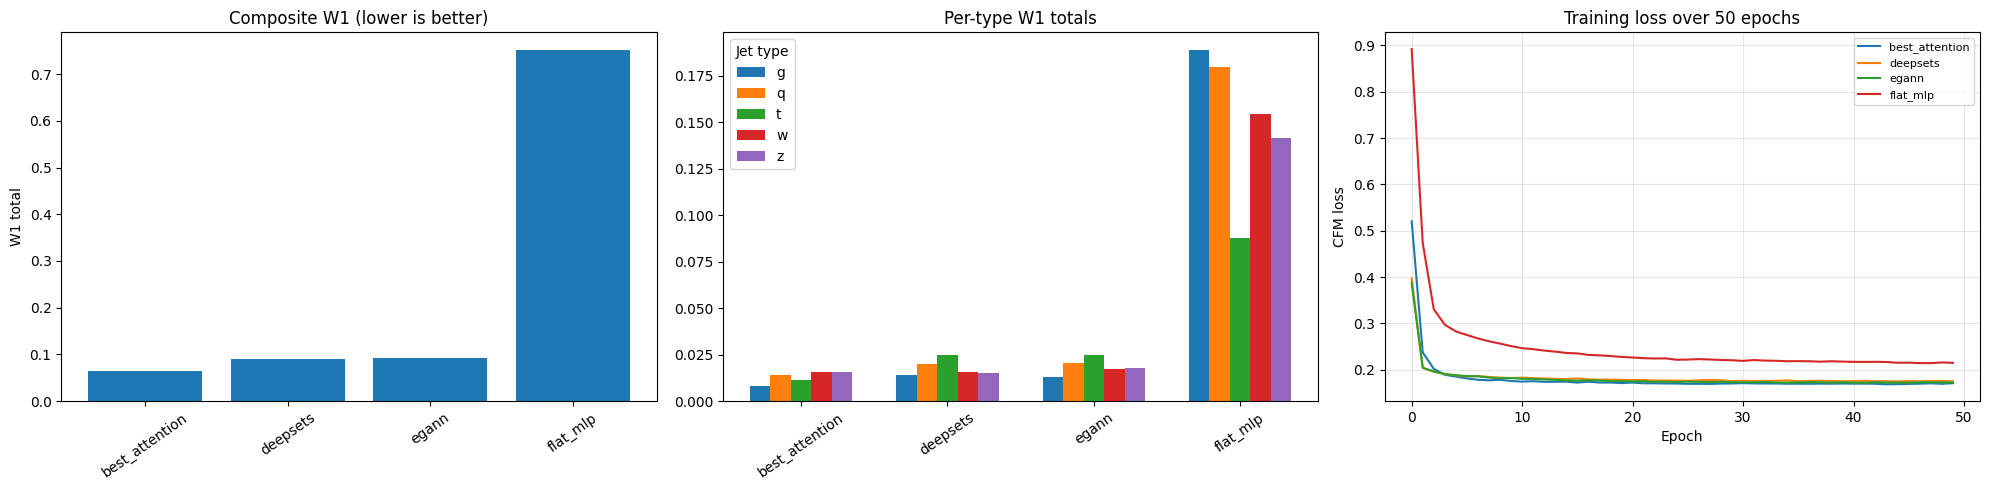

In [11]:
model_names = [r["model"] for r in results_summary]
model_totals = [r["w1_total"] for r in results_summary]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Composite W1 ranking
axes[0].bar(model_names, model_totals)
axes[0].set_title("Composite W1 (lower is better)")
axes[0].set_ylabel("W1 total")
axes[0].tick_params(axis="x", rotation=35)

# 2) Per-type totals
x = np.arange(len(model_names))
width = 0.14
for j, jt in enumerate(JET_TYPES):
    vals = [next(r for r in results_summary if r["model"] == name)[f"w1_{jt}"] for name in model_names]
    axes[1].bar(x + (j - 2) * width, vals, width, label=jt)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=35)
axes[1].set_title("Per-type W1 totals")
axes[1].legend(title="Jet type")

# 3) Training loss curves
for name in model_names:
    axes[2].plot(loss_histories[name], label=name)
axes[2].set_title("Training loss over 50 epochs")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("CFM loss")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Optional: print per-observable breakdown for top-2 models
for rank, entry in enumerate(results_summary[:2], start=1):
    name = entry["model"]
    print("\n" + "=" * 70)
    print(f"Rank {rank}: {name} | W1={entry['w1_total']:.5f}")
    print("=" * 70)
    scores = detailed_scores[name]
    print(f"{'Type':>6} | {'Mass':>8} | {'eta':>8} | {'phi':>8} | {'pt':>8} | {'Total':>8}")
    print("-" * 60)
    for jt in JET_TYPES:
        s = scores[jt]
        row_total = sum(s.values())
        print(f"{jt:>6} | {s['mass']:8.5f} | {s['eta']:8.5f} | {s['phi']:8.5f} | {s['pt']:8.5f} | {row_total:8.5f}")


Rank 1: best_attention | W1=0.06467
  Type |     Mass |      eta |      phi |       pt |    Total
------------------------------------------------------------
     g |  0.00220 |  0.00114 |  0.00191 |  0.00266 |  0.00791
     q |  0.00733 |  0.00156 |  0.00115 |  0.00379 |  0.01383
     t |  0.00391 |  0.00307 |  0.00205 |  0.00252 |  0.01155
     w |  0.00801 |  0.00244 |  0.00247 |  0.00260 |  0.01552
     z |  0.00844 |  0.00196 |  0.00242 |  0.00305 |  0.01587

Rank 2: deepsets | W1=0.08940
  Type |     Mass |      eta |      phi |       pt |    Total
------------------------------------------------------------
     g |  0.00696 |  0.00236 |  0.00272 |  0.00193 |  0.01398
     q |  0.01035 |  0.00397 |  0.00348 |  0.00218 |  0.01998
     t |  0.01150 |  0.00542 |  0.00587 |  0.00203 |  0.02481
     w |  0.00951 |  0.00194 |  0.00248 |  0.00149 |  0.01543
     z |  0.01048 |  0.00146 |  0.00142 |  0.00185 |  0.01520


### Note

This trailing cell is intentionally kept as a lightweight placeholder because notebook tooling cannot delete cells directly.

You can safely ignore it (or manually delete it in the UI).